# Tree-based Methods

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import pydot
from IPython.display import Image
from sklearn import tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from six import StringIO  
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, r2_score
from dmba import plotDecisionTree, classificationSummary, regressionSummary

from ISLP import load_data

%matplotlib inline
RANDOM_STATE = 42

## Regression Trees

In [31]:
# Load the Auto dataset
df = load_data('Hitters').dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      263 non-null    int64   
 1   Hits       263 non-null    int64   
 2   HmRun      263 non-null    int64   
 3   Runs       263 non-null    int64   
 4   RBI        263 non-null    int64   
 5   Walks      263 non-null    int64   
 6   Years      263 non-null    int64   
 7   CAtBat     263 non-null    int64   
 8   CHits      263 non-null    int64   
 9   CHmRun     263 non-null    int64   
 10  CRuns      263 non-null    int64   
 11  CRBI       263 non-null    int64   
 12  CWalks     263 non-null    int64   
 13  League     263 non-null    category
 14  Division   263 non-null    category
 15  PutOuts    263 non-null    int64   
 16  Assists    263 non-null    int64   
 17  Errors     263 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  263 non-null    categor

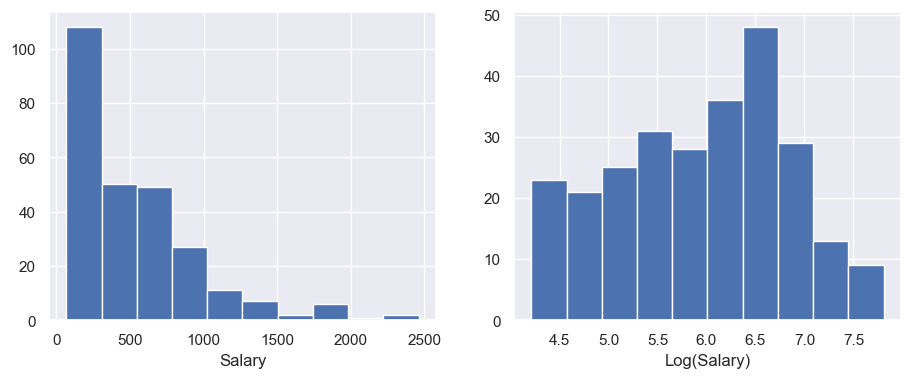

In [32]:
X = df[['Years', 'Hits']]
y = np.log(df.Salary)
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(11,4))
ax1.hist(df.Salary)
ax1.set_xlabel('Salary')
ax2.hist(y)
ax2.set_xlabel('Log(Salary)');

In [33]:
class DecisionTreeModel:
    
    def __init__(self, X_train, X_test, y_train, y_test, max_depth=None, max_leaf_nodes=None, min_samples_split=2, min_samples_leaf=1, model="regression"):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        if model=="regression":
            self.tree = DecisionTreeRegressor(max_depth=max_depth, max_leaf_nodes= max_leaf_nodes, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE)
        else: 
            self.tree = DecisionTreeClassifier(max_depth=max_depth, max_leaf_nodes= max_leaf_nodes, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, random_state=RANDOM_STATE)
        
    def fit(self):
        self.tree.fit(self.X_train, self.y_train)
        return
    
    def predict(self):
        self.y_pred = self.tree.predict(self.X_test)
        return self.y_pred
    
    def calculate_metrics_regression(self):
        y_pred = self.predict()
        rmse = np.sqrt(mean_squared_error(self.y_test, self.y_pred))
        print("RMSE:", rmse)
        return rmse

    def calculate_metrics_classification(self):
        y_pred = self.predict()
        accuracy = accuracy_score(self.y_test, y_pred)
        precision = precision_score(self.y_test, y_pred, average='macro')
        recall = recall_score(self.y_test, y_pred, average='macro')
        f1 = f1_score(self.y_test, y_pred, average='macro')
        print("Accuracy:", accuracy)
        print("Precision:", precision)
        print("Recall:", recall)
        print("F1-Score:", f1)
        return accuracy, precision, recall, f1
        
    def plot(self):
        plt.figure(figsize=(15,10))
        tree.plot_tree(self.tree, filled=True)
        plt.show()
    
    def grid_search(self, X, y, max_depth_range_list, min_sample_split_list):
        param_grid = {
            'max_depth': list(max_depth_range_list), 
            'min_samples_split': list(min_sample_split_list), 
            # 'min_impurity_decrease': min_impurity_decrease_list 
            }
        grid = GridSearchCV(self.tree, param_grid, cv=10,  n_jobs=-1)
        grid.fit(X, y)
        self.tree.set_params(max_depth=grid.best_params_['max_depth'])
        print('Improved score: ', grid.best_score_)
        print('Improved parameters: ', grid.best_params_)
        return grid.best_estimator_, grid.best_params_
    
    def optimal_complexity(self, model="regression"):
        if model == "regression":
            tree = DecisionTreeRegressor()
        else:
            tree =  DecisionTreeClassifier()
        tree.fit(X, y)
        path = tree.cost_complexity_pruning_path(self.X_train,self.y_train)
        alphas, impurities = path.ccp_alphas, path.impurities
        means, std = [], []
        for i in alphas:
            tree.set_params(ccp_alpha=i, random_state=RANDOM_STATE)
            scores = cross_val_score(tree, self.X_train, self.y_train, cv=10)
            means.append(scores.mean())
            std.append(scores.std())
        # keep a record of the values of alpha, mean, standard deviation
        eva_df = pd.DataFrame({'alpha': alphas, 'means': means, 'std': std})
        # eva_df = eva_df.sort_values(['means'], ascending = False)
        print(eva_df)
        print(f"Optimal value: {eva_df.alpha[np.argmin(eva_df.means)]}")
        return eva_df.alpha[np.argmin(eva_df.means)]
        
    def plot_train_test(self, X, y, model="regression"):
        if model == "regression":
            tree = DecisionTreeRegressor()
        else:
            tree =  DecisionTreeClassifier()
        
        tree.fit(X, y)
        path = tree.cost_complexity_pruning_path(self.X_train,self.y_train)
        alphas, impurities = path.ccp_alphas, path.impurities
        accuracy_train, accuracy_val = [], []
        clfs = []
        for i in alphas:
            tree.set_params(ccp_alpha=i, random_state=0)
            tree.fit(self.X_train, self.y_train)
            clfs.append(tree)

            train_y_pred = tree.predict(self.X_train)
            val_y_pred = tree.predict(self.X_test)
            if model == "classification":
                accuracy_train.append(accuracy_score(self.y_train, train_y_pred))
                accuracy_val.append(accuracy_score(self.y_test, val_y_pred))
            else: 
                accuracy_train.append(np.sqrt(mean_squared_error(self.y_train, train_y_pred)))
                accuracy_val.append(np.sqrt(mean_squared_error(self.y_test, val_y_pred)))
        sns.set()
        plt.figure(figsize=(13, 6))
        sns.lineplot(y = accuracy_train, x = alphas, label = 'Train Accuracy')
        sns.lineplot(y = accuracy_val, x = alphas, label = 'Validation Accuracy')
        # plt.xticks(ticks = np.arange(0, 0.05, 0.001), rotation = 90)
        plt.show()

    def plot_importance(self):
        Importance = pd.DataFrame({'Importance':self.tree.feature_importances_*100}, index=self.X_train.columns)
        Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='r', )
        plt.xlabel('Variable Importance')
        plt.gca().legend_ = None


## Regression Tree

In [34]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.10, random_state=RANDOM_STATE)

In [35]:
fit_decision = DecisionTreeModel(X_train, X_test, y_train, y_test)
_ , grid_parameters =fit_decision.grid_search(X,y, [1,2,3,4,5], [3,4,5,6,7,8])
print('Improved parameters: ', grid_parameters)

Improved score:  0.5389309894779009
Improved parameters:  {'max_depth': 4, 'min_samples_split': 6}
Improved parameters:  {'max_depth': 4, 'min_samples_split': 6}


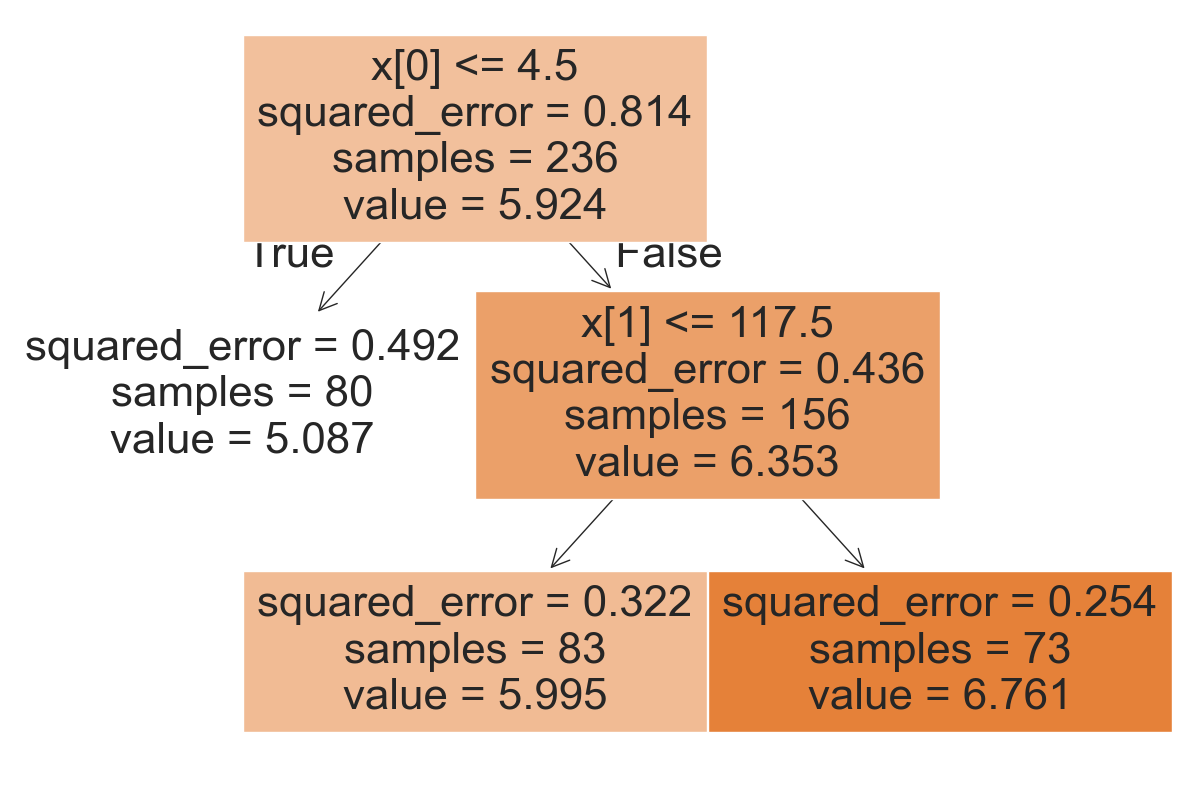

In [36]:
fit_decision = DecisionTreeModel(X_train, X_test, y_train, y_test, max_leaf_nodes=3)
fit_decision.fit()
fit_decision.plot()

In [37]:
rmse = fit_decision.calculate_metrics_regression()

RMSE: 0.500059614559586


In [38]:
fit_decision2 = DecisionTreeModel(X_train, X_test, y_train, y_test, max_depth= 4, min_samples_split= 6)
fit_decision2.fit()
rmse = fit_decision2.calculate_metrics_regression()

RMSE: 0.626590626829945


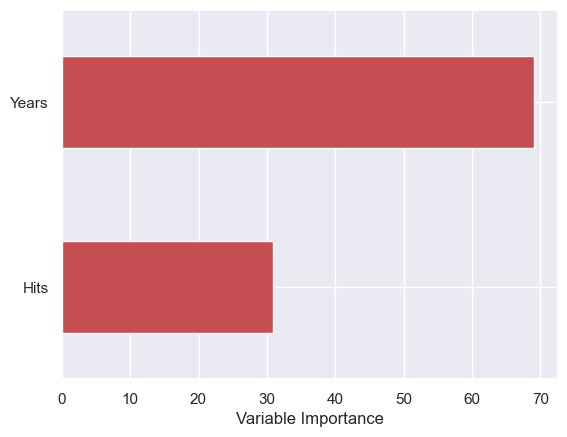

In [39]:
fit_decision2.plot_importance()

### Decision Regions

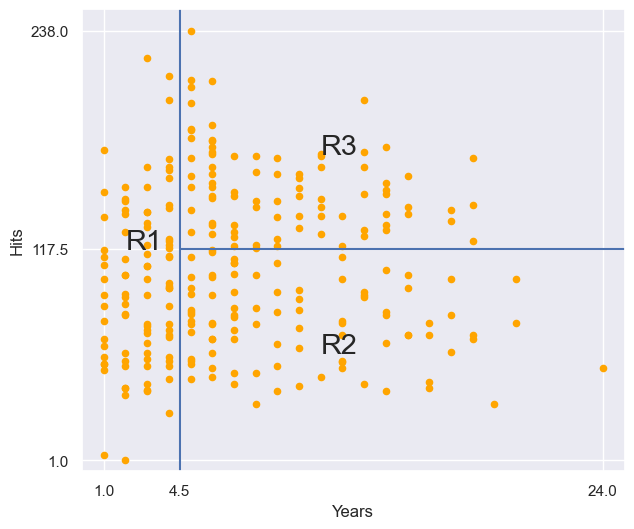

In [50]:
df.plot('Years', 'Hits', kind='scatter', color='orange', figsize=(7,6))
plt.xlim(0,25)
plt.ylim(ymin=-5)
plt.xticks([1, 4.5, 24])
plt.yticks([1, 117.5, 238])
plt.vlines(4.5, ymin=-5, ymax=250)
plt.hlines(117.5, xmin=4.5, xmax=25)
plt.annotate('R1', xy=(2,117.5), fontsize='xx-large')
plt.annotate('R2', xy=(11,60), fontsize='xx-large')
plt.annotate('R3', xy=(11,170), fontsize='xx-large');

## Classification Trees

In [40]:
df2 = pd.read_csv('https://raw.githubusercontent.com/sukhjitsehra/datasets/master/CP322/Heart.csv').drop('Unnamed: 0', axis=1).dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 0 to 301
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [41]:
df2.ChestPain = pd.factorize(df2.ChestPain)[0]
df2.Thal = pd.factorize(df2.Thal)[0]

In [42]:
X2 = df2.drop('AHD', axis=1)
y2 = pd.factorize(df2.AHD)[0]

In [43]:
# train test split
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y2, test_size = 0.10, random_state=RANDOM_STATE)

In [44]:
# fit_clf = DecisionTreeModel(max_depth=None, max_leaf_nodes=6)
fit_clf = DecisionTreeModel(X_train_2, X_test_2, y_train_2, y_test_2, model="classification")
_ , grid_parameters =fit_decision.grid_search(X,y, [1,2,3,4,5], [3,4,5,6,7,8])
print('Improved parameters: ', grid_parameters)

Improved score:  0.5147119025744199
Improved parameters:  {'max_depth': 2, 'min_samples_split': 3}
Improved parameters:  {'max_depth': 2, 'min_samples_split': 3}


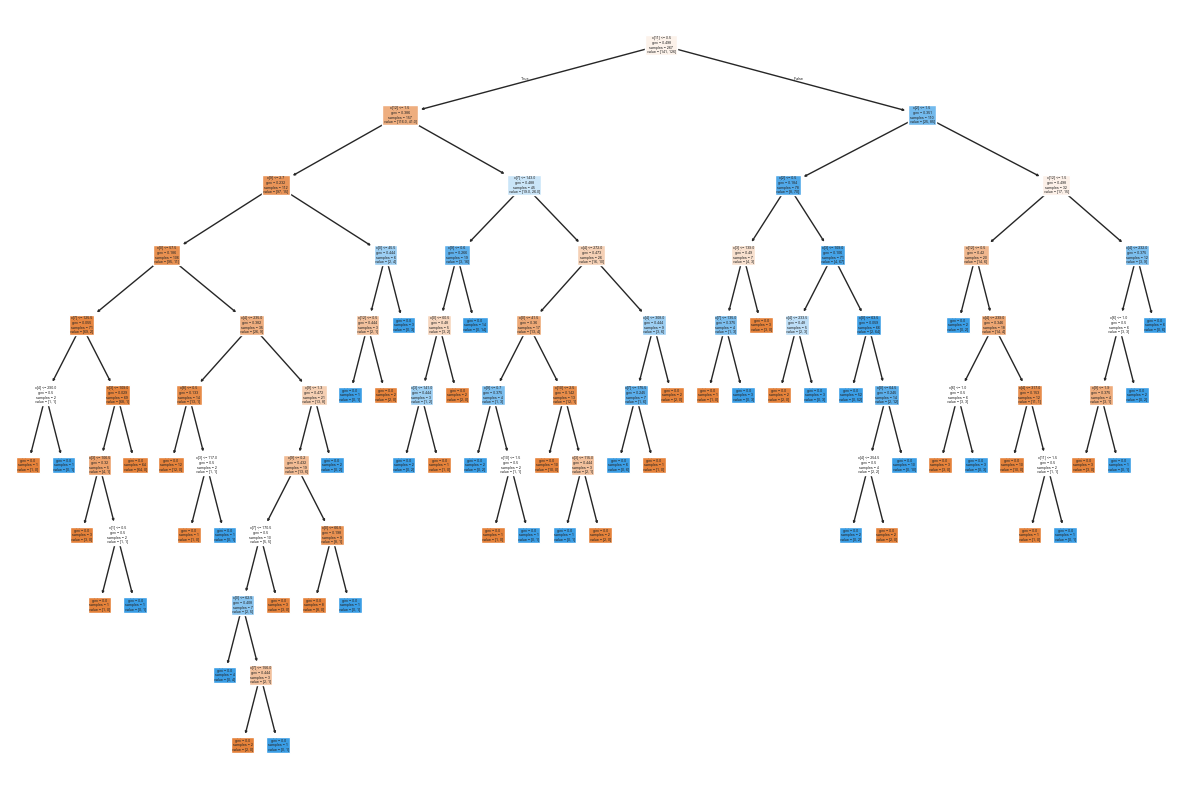

In [45]:
fit_clf.fit()
fit_clf.plot()

In [46]:
fit_clf.calculate_metrics_classification()

Accuracy: 0.8
Precision: 0.784688995215311
Recall: 0.784688995215311
F1-Score: 0.784688995215311


(0.8, 0.784688995215311, 0.784688995215311, 0.784688995215311)

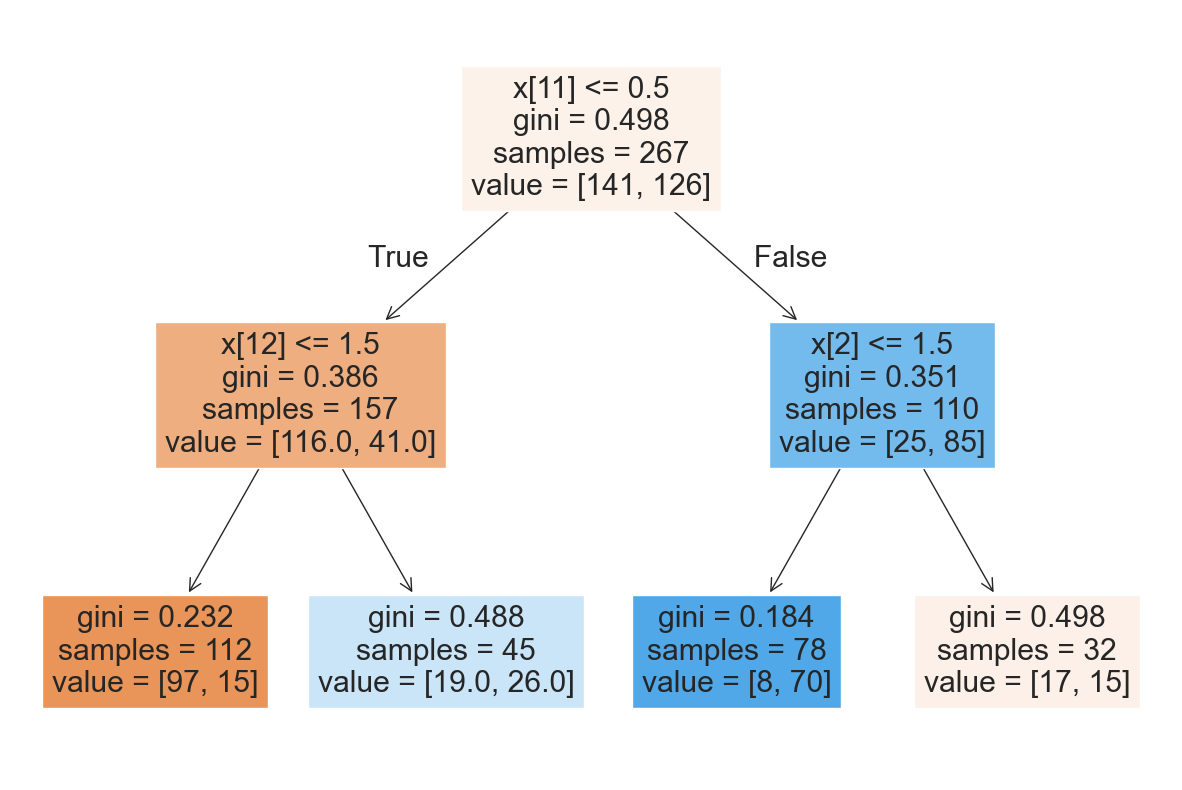

Accuracy: 0.8333333333333334
Precision: 0.8194444444444444
Recall: 0.8301435406698565
F1-Score: 0.8237367802585194


(0.8333333333333334,
 0.8194444444444444,
 0.8301435406698565,
 0.8237367802585194)

In [47]:
fit_clf = DecisionTreeModel(X_train_2, X_test_2, y_train_2, y_test_2, max_depth = 2, min_samples_split=3, model="classification")
fit_clf.fit()
fit_clf.plot()
fit_clf.calculate_metrics_classification()

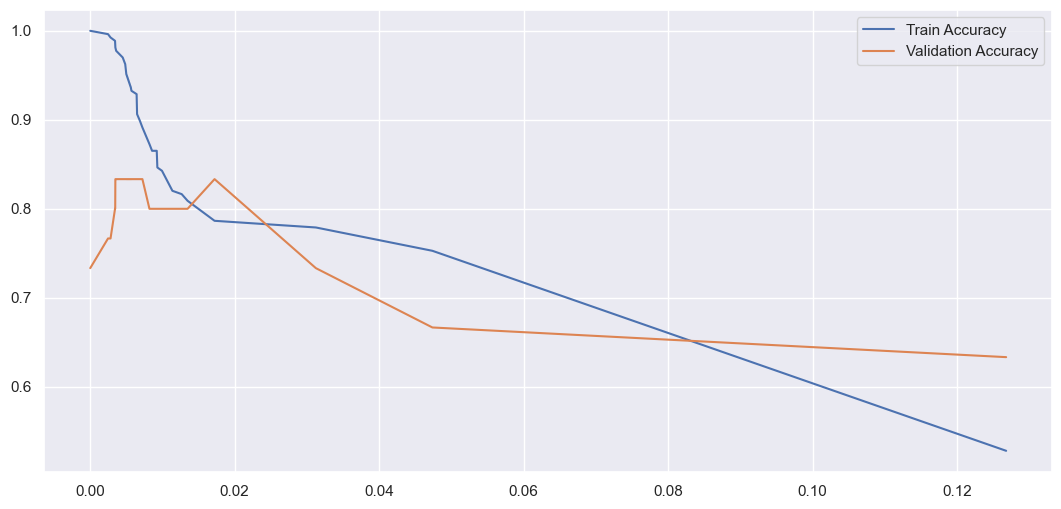

In [48]:
fit_clf.plot_train_test(X2, y2, model="classification")

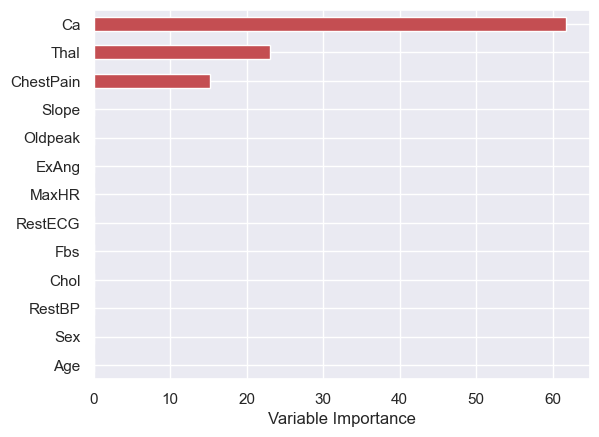

In [49]:
fit_clf.plot_importance()

## Bagging and Random Forests

In [52]:
class EnsembleModels:
    def __init__(self, X, y, model_type, random_state=RANDOM_STATE):
        self.X = X
        self.y = y
        self.model_type = model_type
        self.random_state = random_state
        self.models = {
            'Random Forest': RandomForestRegressor(random_state=random_state),
            'Bagging': BaggingRegressor(random_state=random_state),
            'Boosting': GradientBoostingRegressor(random_state=random_state)
        }
        self.best_params = {}
        self.best_score = 0
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=random_state)
        self.model = self.models[model_type]
    
    def fit(self, tune_fit="yes"):
        if tune_fit=="yes" and self.model_type=='Random Forest':
            param_grid = { 
                    'n_estimators': [200, 700],
                    'max_features': ['sqrt', 'log2']
                }
            grid_search = GridSearchCV(self.model, param_grid=param_grid, cv=10, scoring='neg_mean_squared_error')
            grid_search.fit(self.X_train, self.y_train)
            self.best_params = grid_search.best_params_
            self.model = grid_search.best_estimator_
        elif tune_fit=="yes" and self.model_type=='Boosting':
            aram_grid = { 
                    'n_estimators': [200, 700],
                    'max_features': ['None']
                }
            grid_search = GridSearchCV(self.model, param_grid=param_grid, cv=10, scoring='neg_mean_squared_error')
            grid_search.fit(self.X_train, self.y_train)
            self.best_params = grid_search.best_params_
            self.model = grid_search.best_estimator_
            self.model.fit(self.X_train, self.y_train)
        else: 
            self.model.fit(self.X_train, self.y_train)
            
    def predict(self):
        return self.model.predict(self.X_test)
    
    def score(self):
        y_pred = self.predict()
        return mean_squared_error(self.y_test, y_pred), r2_score(self.y_test, y_pred)
    
    def plot_decision_tree(self):
        if self.model_type != 'Random Forest':
            print("Error: This function is only applicable to Random Forest models.")
            return
        # Extract the first tree from the forest
        estimator = self.model.estimators_[0]

        # Plot the decision tree
        plt.figure(figsize=(12, 8))
        tree.plot_tree(estimator, filled=True)
        plt.show()

    def plot_feature_importance(self, model_type, feature_names):
        if model_type in ["Random Forest", "Bagging"]:
            importances = self.model.feature_importances_
            indices = np.argsort(importances)

            plt.title("Feature Importance")
            plt.barh(range(len(indices)), importances[indices], color='b', align='center')
            plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
            plt.xlabel("Relative Importance")
            plt.show()
        elif model_type == "Boosting":
            from xgboost import plot_importance
            plot_importance(self.model)
            plt.show()
        else:
            raise ValueError("Invalid model type. Choose from 'random_forest', 'bagging', or 'boosting'.")
     


In [53]:
fit_reg = EnsembleModels(X_train,y_train, model_type= 'Random Forest')

In [54]:
fit_reg.fit(tune_fit='yes') # 'yes' to tune the hyper parameter and fit, 'no' otherwise
mse, r2 = fit_reg.score()
print(mse)
print(r2)

0.25863432499566347
0.6569242251665756


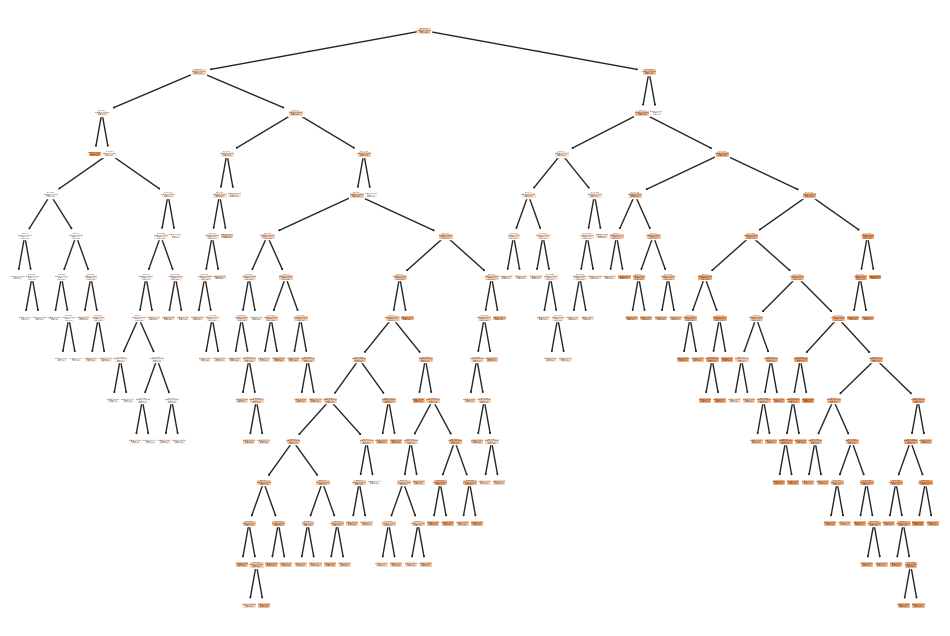

In [55]:
fit_reg.plot_decision_tree()

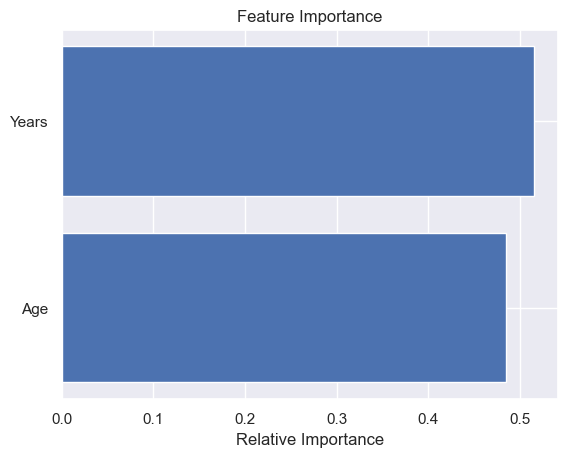

In [56]:
fit_reg.plot_feature_importance(model_type='Random Forest', feature_names=['Years', 'Age'])